# ipynb/rgcnformer_cls_res_nofont_cluster2.ipynb - RGCNFormer 分类结果(聚类2,无字体) / RGCNFormer classification (cluster 2, no font)

## 项目背景 / Background
RGCNFormer 分类结果(聚类2,无字体)
RGCNFormer classification (cluster 2, no font)

## 功能模块 / Modules
- 聚类2 版分类结果
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: ipynb/rgcnformer_cls_res_nofont_cluster.ipynb
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



# 分类结果聚类热力图

使用 ComplexHeatmap 绘制带行聚类的性能热力图，展示不同类别之间性能的相似性。

In [1]:
# 加载所需的包
library(ComplexHeatmap)
library(circlize)
library(grid)
library(dplyr)
library(readr)

Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.18
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

In [2]:
# 读取数据
df <- read.csv("data/res.csv")

# 定义指标顺序
metric_levels <- c("Acc", "Precision", "Recall", "AUC", "F1", "MCC", "AUPRC", "Sn", "Sp")

# 转换为矩阵：行 = Class，列 = 指标
mat <- df %>%
  select(all_of(metric_levels)) %>%
  as.matrix()
rownames(mat) <- df$Class

dim(mat)
print(mat)

[1] 12  9

             Acc Precision Recall    AUC     F1    MCC  AUPRC     Sn     Sp
0 (Am)    0.8386    0.7892 0.9241 0.8895 0.8513 0.6873 0.8456 0.9241 0.7532
1 (Atol)  0.9979    0.9959 0.9999 0.9989 0.9979 0.9958 0.9981 0.9999 0.9959
2 (Cm)    0.9626    0.9530 0.9733 0.9726 0.9630 0.9255 0.9244 0.9733 0.9520
3 (Gm)    0.9516    0.9495 0.9539 0.9654 0.9517 0.9032 0.9248 0.9539 0.9493
4 (Tm)    0.9749    0.9728 0.9772 0.9857 0.9750 0.9499 0.9808 0.9772 0.9726
5 (Y)     0.6830    0.6151 0.9780 0.7758 0.7552 0.4533 0.8024 0.9780 0.3880
6 (ac4C)  0.9423    0.9122 0.9788 0.9639 0.9443 0.8869 0.9433 0.9788 0.9058
7 (m1A)   0.9325    0.9343 0.9305 0.9738 0.9324 0.8651 0.9729 0.9305 0.9346
8 (m5C)   0.9716    0.9746 0.9685 0.9848 0.9715 0.9432 0.9731 0.9685 0.9748
9 (m6A)   0.9416    0.9128 0.9764 0.9845 0.9436 0.8854 0.9789 0.9764 0.9068
10 (m6Am) 0.9903    0.9809 1.0000 0.9901 0.9903 0.9807 0.9826 1.0000 0.9805
11 (m7G)  0.9492    0.9414 0.9581 0.9751 0.9497 0.8986 0.9643 0.9581 0.9404


In [3]:
file.exists("/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf")
file.exists("/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf")

[1] TRUE

[1] TRUE

pdf 
  2

pdf 
  2

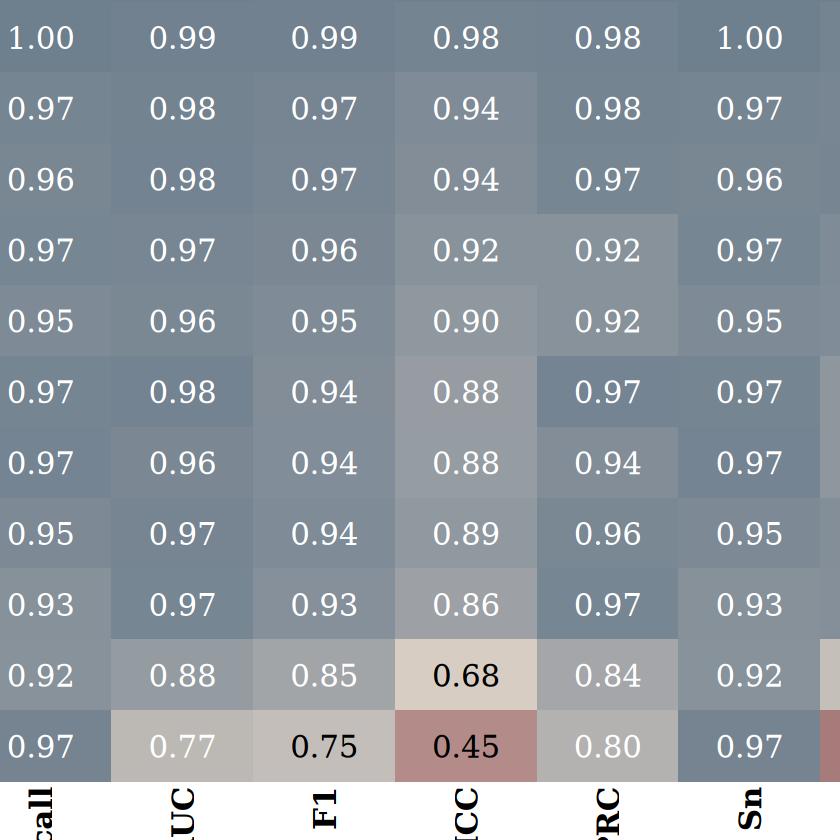

In [4]:
library(ComplexHeatmap)
library(circlize)
library(grid)

# 颜色与逻辑设置 (莫兰迪配色: 玫瑰→燕麦→灰蓝)
min_val <- min(mat, na.rm = TRUE)
max_val <- max(mat, na.rm = TRUE)
col_fun = colorRamp2(
  c(min_val, (min_val + max_val) / 2, max_val), 
  c("#A87B7B", "#D9CFC4", "#6E7F8E")
)

get_text_color <- function(value) {
  norm_val <- (value - min_val) / (max_val - min_val)
  ifelse(norm_val > 0.6, "white", "black")
}

# 创建 Heatmap 对象
ht <- Heatmap(mat, 
        name = "Performance",
        col = col_fun,
        cluster_rows = TRUE,          
        cluster_columns = FALSE,      
        show_row_dend = TRUE,          
        row_dend_gp = gpar(col = "#4A4E69", lwd = 2.0), # 莫兰迪深灰蓝连接线
        row_dend_width = unit(4, "cm"),
        width = unit(3.0, "cm") * ncol(mat),  # 增加宽度适配 18pt
        height = unit(1.5, "cm") * nrow(mat),
        
        column_names_gp = gpar(fontfamily = "serif", fontface = "bold", fontsize = 18),
        row_names_gp = gpar(fontfamily = "serif", fontsize = 18),
        
        heatmap_legend_param = list(
          title = "Performance (%)",
          title_gp = gpar(fontfamily = "serif", fontface = "bold", fontsize = 18),
          labels_gp = gpar(fontfamily = "serif", fontsize = 18),
          grid_height = unit(1, "cm")
        ),
        
        cell_fun = function(j, i, x, y, width, height, fill) {
          val <- mat[i, j]
          grid.text(sprintf("%.2f", floor(val * 100) / 100), x, y, 
                    gp = gpar(fontfamily = "serif", fontsize = 18, col = get_text_color(val)))
        })

# 保存为 PDF (使用原生字体，数字在 Illustrator 中可编辑)
pdf("png3/rgcnformer_cls_heatmap_complex2.pdf", width = 18, height = 12)
  draw(ht, heatmap_legend_side = "right")
dev.off()

# 保存为 PNG (高分辨率)
png("png3/rgcnformer_cls_heatmap_complex2.png", width = 18, height = 12, units = "in", res = 300)
  draw(ht, heatmap_legend_side = "right")
dev.off()

# 在 Jupyter/IDE 中显示
draw(ht, heatmap_legend_side = "right")

## 说明

- **行聚类**：✓ 已开启，性能相似的类别会被聚合在一起，左侧显示树状图
- **列聚类**：✓ 已关闭，保持原始指标顺序
- **颜色映射**：✓ 莫兰迪配色，低值(玫瑰 #A87B7B) → 中值(燕麦 #D9CFC4) → 高值(灰蓝 #6E7F8E)
- **文字颜色**：✓ 根据背景深浅自动切换，深色背景用白色，浅色背景用黑色
- **数值标注**：✓ 单元格显示 Value × 100，保留两位小数
- **单元格尺寸**：✓ 设置合理宽度和高度
- **树状连接线**：✓ 已添加 `row_dend_gp = gpar(col = "black", lwd = 1)` 可调参数
- **树状图尺寸**：✓ 已添加 `row_dend_width = unit(2, "cm")` 可调树状图宽度


*字体说明：使用 R 内置 serif 字体渲染，PDF 中数字为可编辑文字对象。在 Illustrator 中打开后可直接选中数字，批量替换为 Times New Roman。*

**调整树状连接线**：修改 `row_dend_gp` 参数
- `col = "black"` - 改变连接线颜色，如 `"gray"`, `"#333333"`
- `lwd = 1` - 改变线宽，越大越粗，如 `1.5`, `2`

**调整树状图大小**：修改 `row_dend_width` 参数
- `unit(2, "cm")` - 树状图占用的宽度（垂直方向高度），增大数值让树状图更高